In [31]:
import os
import numpy as np
from matplotlib import animation
import matplotlib.pyplot as plt
import japanize_matplotlib
from IPython import display

https://www.kaggle.com/code/inversion/visualizing-contrails

# OpenContrails データセットドキュメント

衛星画像は元々[GOES-16 Advanced Baseline Imager (ABI)](https://www.goes-r.gov/spacesegment/abi.html)から取得されており、[Google Cloud Storage](https://console.cloud.google.com/storage/browser/gcp-public-data-goes-16/)で公開されています。元のフルディスク画像は、バイリニア リサンプリングを使用して再投影され、ローカルシーン画像が生成されました。飛行機雲は時間的コンテキストで識別しやすいため、10分間隔の画像シーケンスが提供されています。各サンプルには、正確に1つのラベル付きフレームが含まれています。

データセットの詳細については、プレプリント論文をご覧ください: [OpenContrails: Benchmarking Contrail Detection on GOES-16 ABI](https://arxiv.org/abs/2304.02122)。

## ファイル
`{record_id}`という名前の各サブディレクトリには、単一のサンプルに対応するnumpy `.npy`形式のバイナリファイルが提供されています:

* **`band_{08-16}.npy`**: サイズが`H x W x T`の配列。`T = n_times_before + n_times_after + 1`はシーケンス内の画像数を表します。ラベル付きフレームの前後にそれぞれ`n_times_before`と`n_times_after`の画像があります。このデータセットでは、すべてのサンプルで`n_times_before=4`、`n_times_after=3`です。各バンドは異なる波長の赤外線チャンネルを表し、校正パラメータに基づいて輝度温度に変換されています。ファイル名の数字はGOES-16 ABIのバンド番号に対応しています。ABIバンドの詳細は[こちら](https://www.goes-r.gov/mission/ABI-bands-quick-info.html)をご覧ください。
* **`human_individual_masks.npy`**: サイズが`H x W x 1 x R`の配列。各サンプルは`R`人の個別の人間ラベラーによってラベル付けされています。`R`はすべてのサンプルで同じではありません。ラベル付きマスクの値は0または1で、`band_{08-16}.npy`の`(n_times_before+1)`番目の画像に対応します。これらは訓練セットのみで利用可能です。
* **`human_pixel_masks.npy`**: サイズが`H x W x 1`のバイナリ正解データを含む配列。ピクセルは、ラベラーの半数以上が飛行機雲としてラベル付けした場合、評価において飛行機雲ピクセルとみなされます。

**`{train/validation}_metadata.json`**: 衛星画像を再現するためのタイムスタンプと投影パラメータが含まれています。

In [46]:
!ls ../data/train/1704010292581573769 

band_08.npy  band_11.npy  band_14.npy  human_individual_masks.npy
band_09.npy  band_12.npy  band_15.npy  human_pixel_masks.npy
band_10.npy  band_13.npy  band_16.npy


band11の形状: (256, 256, 8)
band14の形状: (256, 256, 8)
band15の形状: (256, 256, 8)
human_pixel_maskの形状: (256, 256, 1)
human_individual_maskの形状: (256, 256, 1, 4)
　個別ラベラー数: 4


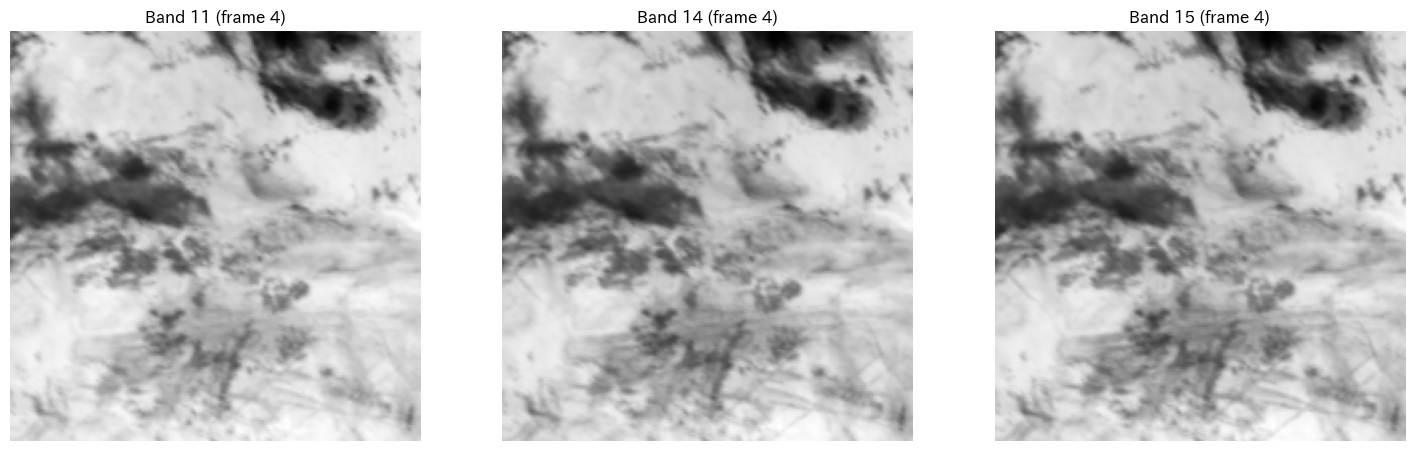

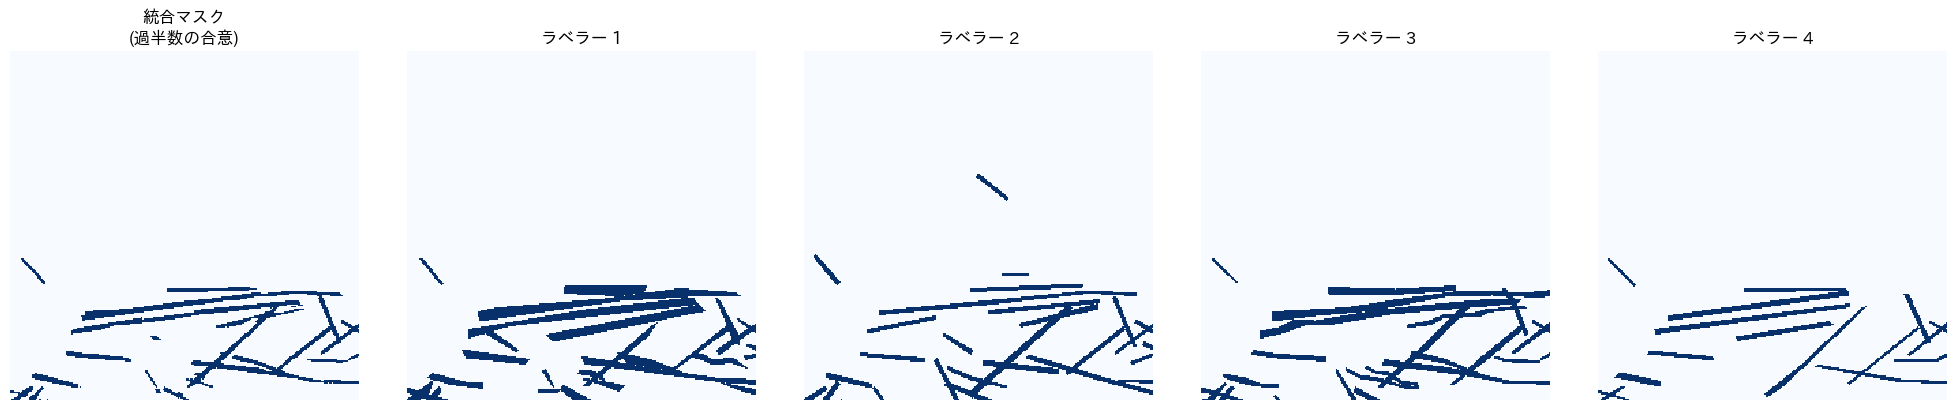

In [44]:
BASE_DIR = '../data/train'
N_TIMES_BEFORE = 4
record_id = '1704010292581573769'

with open(os.path.join(BASE_DIR, record_id, 'band_11.npy'), 'rb') as f:
    band11 = np.load(f)
with open(os.path.join(BASE_DIR, record_id, 'band_14.npy'), 'rb') as f:
    band14 = np.load(f)
with open(os.path.join(BASE_DIR, record_id, 'band_15.npy'), 'rb') as f:
    band15 = np.load(f)
with open(os.path.join(BASE_DIR, record_id, 'human_pixel_masks.npy'), 'rb') as f:
    human_pixel_mask = np.load(f)
with open(os.path.join(BASE_DIR, record_id, 'human_individual_masks.npy'), 'rb') as f:
    human_individual_mask = np.load(f)

# データの形状を確認
print(f"band11の形状: {band11.shape}")
print(f"band14の形状: {band14.shape}")
print(f"band15の形状: {band15.shape}")
print(f"human_pixel_maskの形状: {human_pixel_mask.shape}")
print(f"human_individual_maskの形状: {human_individual_mask.shape}")
print(f"　個別ラベラー数: {human_individual_mask.shape[-1]}")

# 各バンドの可視化（ラベル付きフレームのタイミング）
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(band11[..., N_TIMES_BEFORE], cmap='gray')
axes[0].set_title(f'Band 11 (frame {N_TIMES_BEFORE})')
axes[0].axis('off')

axes[1].imshow(band14[..., N_TIMES_BEFORE], cmap='gray')
axes[1].set_title(f'Band 14 (frame {N_TIMES_BEFORE})')
axes[1].axis('off')

axes[2].imshow(band15[..., N_TIMES_BEFORE], cmap='gray')
axes[2].set_title(f'Band 15 (frame {N_TIMES_BEFORE})')
axes[2].axis('off')

# マスクの可視化
n_labelers = human_individual_mask.shape[-1]
fig, axes = plt.subplots(1, n_labelers + 1, figsize=(4 * (n_labelers + 1), 4))

# 統合されたピクセルマスク
axes[0].imshow(human_pixel_mask.squeeze(), cmap='Blues', interpolation='none')
axes[0].set_title('統合マスク\n(過半数の合意)')
axes[0].axis('off')

# 個別ラベラーのマスク
for i in range(n_labelers):
    axes[i + 1].imshow(human_individual_mask[..., 0, i], cmap='Blues', interpolation='none')
    axes[i + 1].set_title(f'ラベラー {i + 1}')
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

### 各バンドとマスクの可視化
読み込んだデータの形状と内容を確認します。

### バンドを組み合わせて疑似カラー画像を作成
GOESで飛行機雲を表示するために、「アッシュ(灰)」カラースキームを使用します。このカラースキームはもともと大気中の火山灰を表示するために開発されましたが、飛行機雲を含む薄い巻雲を表示するのにも有用です。このカラースキームでは、飛行機雲は濃い青色として画像に表示されます。

ここでは、Kulik et al.によって開発された、飛行機雲に調整されたわずかに異なるバンドと境界値を使用する、アッシュカラースキームの改良版を使用していることに注意してください。

参考文献:
 - Ash Color Scheme (page 7): https://eumetrain.org/sites/default/files/2020-05/RGB_recipes.pdf

In [36]:
_T11_BOUNDS = (243, 303)
_CLOUD_TOP_TDIFF_BOUNDS = (-4, 5)
_TDIFF_BOUNDS = (-4, 2)

def normalize_range(data, bounds):
    """Maps data to the range [0, 1]."""
    return (data - bounds[0]) / (bounds[1] - bounds[0])

r = normalize_range(band15 - band14, _TDIFF_BOUNDS)
g = normalize_range(band14 - band11, _CLOUD_TOP_TDIFF_BOUNDS)
b = normalize_range(band14, _T11_BOUNDS)
false_color = np.clip(np.stack([r, g, b], axis=2), 0, 1)

## Visualize data

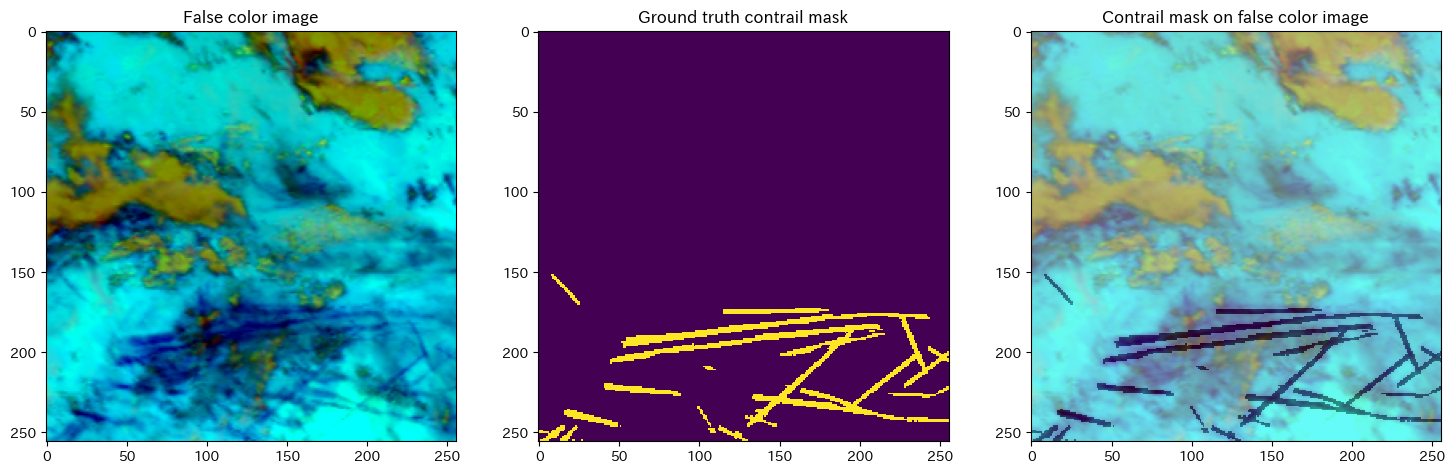

In [37]:
img = false_color[..., N_TIMES_BEFORE]

plt.figure(figsize=(18, 6))
ax = plt.subplot(1, 3, 1)
ax.imshow(img)
ax.set_title('False color image')

ax = plt.subplot(1, 3, 2)
ax.imshow(human_pixel_mask, interpolation='none')
ax.set_title('Ground truth contrail mask')

ax = plt.subplot(1, 3, 3)
ax.imshow(img)
ax.imshow(human_pixel_mask, cmap='Reds', alpha=.4, interpolation='none')
ax.set_title('Contrail mask on false color image');

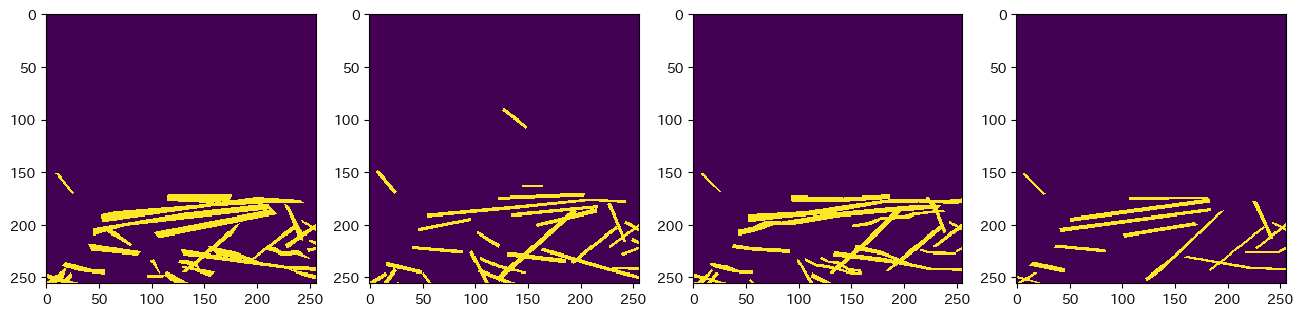

In [38]:
# Individual human masks
n = human_individual_mask.shape[-1]
plt.figure(figsize=(16, 4))
for i in range(n):
    plt.subplot(1, n, i+1)
    plt.imshow(human_individual_mask[..., i], interpolation='none')

In [39]:
# Animation
fig = plt.figure(figsize=(6, 6))
im = plt.imshow(false_color[..., 0])
def draw(i):
    im.set_array(false_color[..., i])
    return [im]
anim = animation.FuncAnimation(
    fig, draw, frames=false_color.shape[-1], interval=500, blit=True
)
plt.close()
display.HTML(anim.to_jshtml())